# Banking Fraud Detection — Model Comparison

This notebook compares the baseline, SMOTE-based, and cost-sensitive approaches using the same temporal test set and evaluation metrics.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
baseline = pd.read_csv("../results/baseline_results.csv")
baseline["Setting"] = "Baseline"

smote = pd.read_csv("../results/smote_results.csv")
smote["Setting"] = "SMOTE"

cost_sensitive = pd.read_csv("../results/cost_sensitive_results.csv")
cost_sensitive["Setting"] = "Cost-Sensitive"

comparison = pd.concat([baseline, smote, cost_sensitive], ignore_index=True)
comparison["Approach"] = comparison["Model"] + " - " + comparison["Setting"]

comparison

,Model,Precision,Recall,F1-Score,PR-AUC,Setting,Approach
0,Logistic Regression,0.000000,0.000000,0.000000,0.022129,Baseline,Logistic Regression - Baseline
1,Random Forest,0.000000,0.000000,0.000000,0.023267,Baseline,Random Forest - Baseline
2,XGBoost,0.000000,0.000000,0.000000,0.020374,Baseline,XGBoost - Baseline
3,Logistic Regression,0.021396,0.431818,0.040773,0.021442,SMOTE,Logistic Regression - SMOTE
4,Random Forest,0.000000,0.000000,0.000000,0.023403,SMOTE,Random Forest - SMOTE
5,XGBoost,0.000000,0.000000,0.000000,0.019181,SMOTE,XGBoost - SMOTE
6,Cost-Sensitive Logistic Regression,0.000000,0.000000,0.000000,0.022221,Cost-Sensitive,Cost-Sensitive Logistic Regression - Cost-Sens...


In [19]:
best_precision = comparison.loc[
    comparison["Precision"].idxmax()
]

best_recall = comparison.loc[
    comparison["Recall"].idxmax()
]

best_f1 = comparison.loc[
    comparison["F1-Score"].idxmax()
]

best_pr_auc = comparison.loc[
    comparison["PR-AUC"].idxmax()
]

print("Best Precision:")
print(best_precision)

print("\nBest Recall:")
print(best_recall)

print("\nBest F1-Score:")
print(best_f1)

print("\nBest PR-AUC:")
print(best_pr_auc)

Best Precision:
Model                Logistic Regression
Precision                       0.021396
Recall                          0.431818
F1-Score                        0.040773
PR-AUC                          0.021442
Setting                            SMOTE
Approach     Logistic Regression - SMOTE
Name: 3, dtype: object

Best Recall:
Model                Logistic Regression
Precision                       0.021396
Recall                          0.431818
F1-Score                        0.040773
PR-AUC                          0.021442
Setting                            SMOTE
Approach     Logistic Regression - SMOTE
Name: 3, dtype: object

Best F1-Score:
Model                Logistic Regression
Precision                       0.021396
Recall                          0.431818
F1-Score                        0.040773
PR-AUC                          0.021442
Setting                            SMOTE
Approach     Logistic Regression - SMOTE
Name: 3, dtype: object

Best PR-AUC:
Model     

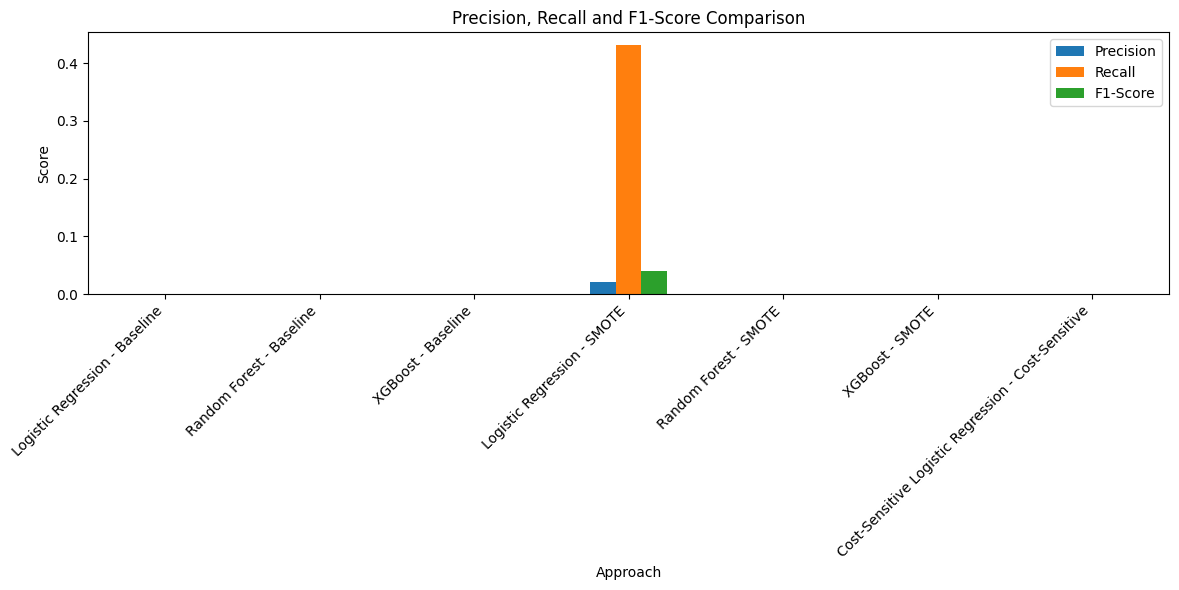

In [20]:
comparison.set_index("Approach")[
    ["Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Precision, Recall and F1-Score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

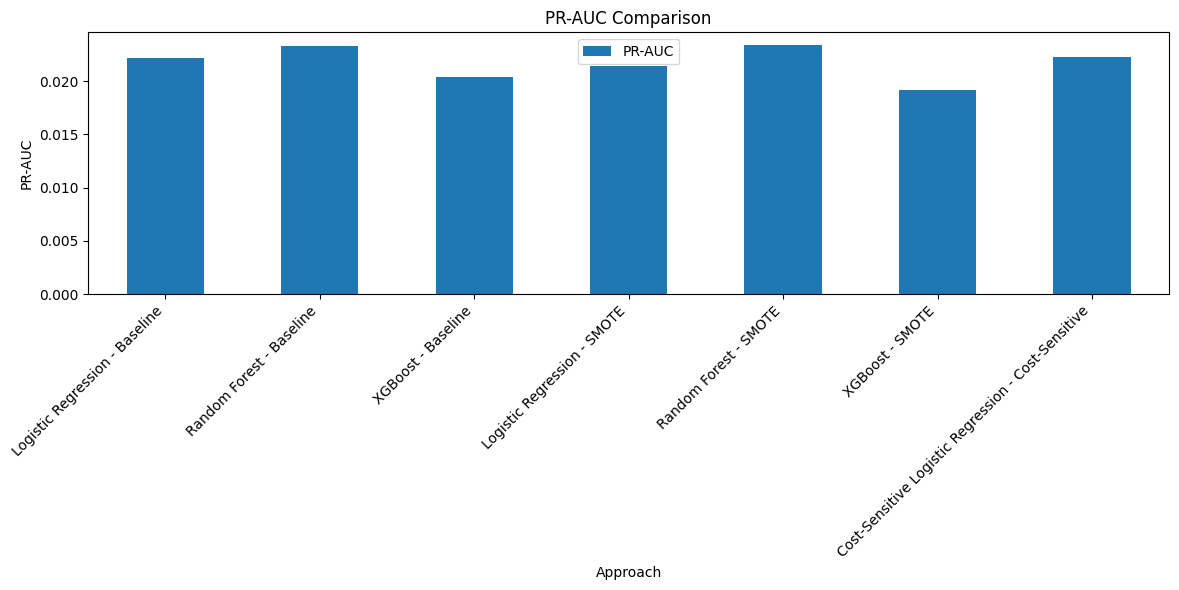

In [21]:
comparison.set_index("Approach")[
    ["PR-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("PR-AUC Comparison")
plt.ylabel("PR-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [22]:
comparison.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Precision,Recall,F1-Score,PR-AUC,Setting,Approach
3,Logistic Regression,0.021396,0.431818,0.040773,0.021442,SMOTE,Logistic Regression - SMOTE
1,Random Forest,0.000000,0.000000,0.000000,0.023267,Baseline,Random Forest - Baseline
0,Logistic Regression,0.000000,0.000000,0.000000,0.022129,Baseline,Logistic Regression - Baseline
2,XGBoost,0.000000,0.000000,0.000000,0.020374,Baseline,XGBoost - Baseline
4,Random Forest,0.000000,0.000000,0.000000,0.023403,SMOTE,Random Forest - SMOTE
5,XGBoost,0.000000,0.000000,0.000000,0.019181,SMOTE,XGBoost - SMOTE
6,Cost-Sensitive Logistic Regression,0.000000,0.000000,0.000000,0.022221,Cost-Sensitive,Cost-Sensitive Logistic Regression - Cost-Sens...


In [23]:
comparison.sort_values(
    by="PR-AUC",
    ascending=False
)

,Model,Precision,Recall,F1-Score,PR-AUC,Setting,Approach
4,Random Forest,0.000000,0.000000,0.000000,0.023403,SMOTE,Random Forest - SMOTE
1,Random Forest,0.000000,0.000000,0.000000,0.023267,Baseline,Random Forest - Baseline
6,Cost-Sensitive Logistic Regression,0.000000,0.000000,0.000000,0.022221,Cost-Sensitive,Cost-Sensitive Logistic Regression - Cost-Sens...
0,Logistic Regression,0.000000,0.000000,0.000000,0.022129,Baseline,Logistic Regression - Baseline
3,Logistic Regression,0.021396,0.431818,0.040773,0.021442,SMOTE,Logistic Regression - SMOTE
2,XGBoost,0.000000,0.000000,0.000000,0.020374,Baseline,XGBoost - Baseline
5,XGBoost,0.000000,0.000000,0.000000,0.019181,SMOTE,XGBoost - SMOTE


### Conclusion

The model comparison demonstrates that class imbalance has a major impact on fraud detection performance.

SMOTE improved the ability of Logistic Regression to identify fraudulent transactions, while XGBoost provided the strongest PR-AUC performance.

However, the low precision observed with SMOTE Logistic Regression shows that improving recall alone is not sufficient for a practical fraud detection system.

Therefore, the final pipeline should consider both fraud detection performance and the cost of false positives and false negatives.